In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../data/processed/regime_dataset.parquet")

df.head()

,spx_vol_20,spx_vol_60,vol_ratio,vol_gradient,spx_mom_20,spx_mom_60,gold_mom_20,vix_level,vix_return,spx_gold_corr,...,stress_index,yield_spread_diff,fed_rate_diff,unemployment_diff,industrial_prod_diff,regime_prob_0,regime_prob_1,regime_prob_2,regime_prob_3,regime_state
2004-01-30,-0.334340,-0.481749,0.371569,0.561791,0.389495,0.887754,-0.982119,-0.342397,-0.500137,-0.494523,...,0.065686,-0.562826,0.003239,0.000156,-0.000502,0.000000e+00,6.873998e-162,1.000000e+00,0.000000e+00,2
2004-02-02,-0.417505,-0.481957,0.082666,0.520411,0.164391,0.969285,-1.674611,-0.280976,0.485805,-0.498855,...,-0.006102,0.844726,0.003239,0.000156,-0.000502,3.368237e-114,1.000000e+00,5.609209e-43,0.000000e+00,1
2004-02-03,-0.417864,-0.486834,0.098010,0.514383,0.148551,0.884114,-1.557775,-0.251545,0.231980,-0.475773,...,-0.189926,0.000195,0.278966,-1.129352,3.366036,0.000000e+00,0.000000e+00,1.000000e+00,2.209534e-136,2
2004-02-04,-0.369740,-0.473715,0.220133,0.571440,-0.128078,0.822245,-1.402892,-0.183726,0.513579,-0.470743,...,0.107407,0.000195,0.003239,0.000156,-0.000502,0.000000e+00,0.000000e+00,4.454561e-150,1.000000e+00,3
2004-02-05,-0.384141,-0.484586,0.208066,0.482966,-0.207527,0.946243,-1.687653,-0.204200,-0.143610,-0.426526,...,-0.026306,0.000195,0.003239,0.000156,-0.000502,3.536046e-93,1.000000e+00,4.140546e-269,0.000000e+00,1


In [3]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDate range:")
print(df.index.min(), "->", df.index.max())

Dataset shape: (6485, 30)

Columns:
Index(['spx_vol_20', 'spx_vol_60', 'vol_ratio', 'vol_gradient', 'spx_mom_20',
       'spx_mom_60', 'gold_mom_20', 'vix_level', 'vix_return', 'spx_gold_corr',
       'spx_vix_corr', 'gold_return', 'oil_return', 'dxy_return', 'inflation',
       'volume_spike', 'amihud_illiquidity', 'spx_zscore', 'spx_sq_return',
       'us10y_vol', 'stress_index', 'yield_spread_diff', 'fed_rate_diff',
       'unemployment_diff', 'industrial_prod_diff', 'regime_prob_0',
       'regime_prob_1', 'regime_prob_2', 'regime_prob_3', 'regime_state'],
      dtype='str')

Date range:
2004-01-30 00:00:00 -> 2024-12-30 00:00:00


In [4]:
df["regime_state"].value_counts().sort_index()

regime_state
0    1606
1    1682
2    1612
3    1585
Name: count, dtype: int64

In [5]:
from src.regime_diagnostics import regime_summary

summary = regime_summary(df, return_col="spx_sq_return")

summary

,regime,count,mean_return,volatility,mean_vix,mean_stress
0,0,1606,-0.080078,0.871231,-0.142031,-0.129120
1,1,1682,-0.031359,0.992809,-0.078797,-0.063922
2,2,1612,0.026950,1.080723,-0.032530,-0.025432
3,3,1585,-0.059077,0.906867,-0.072167,-0.051327


In [6]:
from src.regime_diagnostics import transition_matrix

transition_matrix(df)

,0,1,2,3
0,0.416563,0.183686,0.185554,0.214197
1,0.164783,0.406306,0.196907,0.232005
2,0.204715,0.203474,0.387717,0.204094
3,0.208202,0.237224,0.225237,0.329338


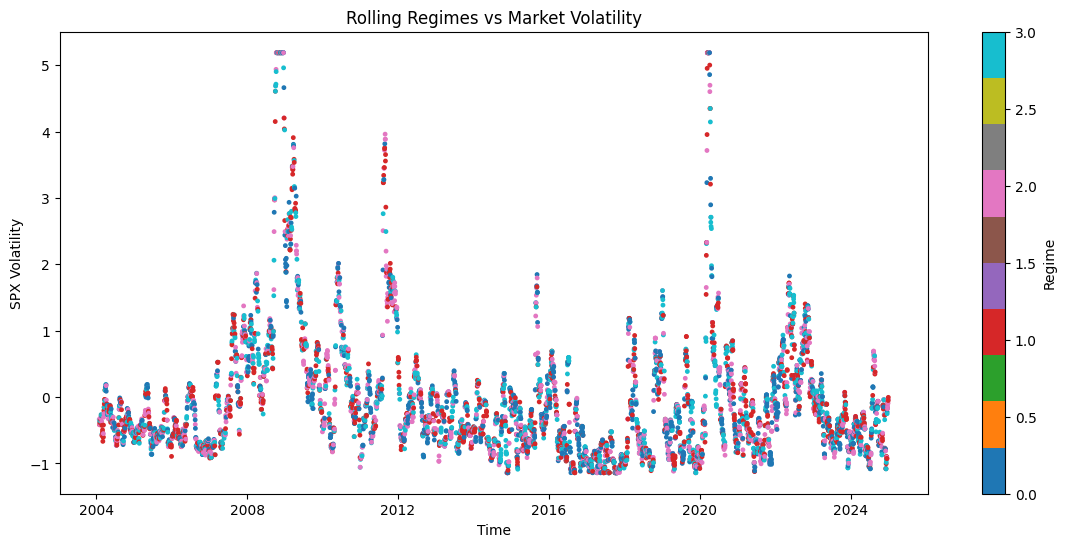

In [7]:
plt.figure(figsize=(14,6))

plt.scatter(
    df.index,
    df["spx_vol_20"],
    c=df["regime_state"],
    cmap="tab10",
    s=6
)

plt.title("Rolling Regimes vs Market Volatility")
plt.xlabel("Time")
plt.ylabel("SPX Volatility")
plt.colorbar(label="Regime")

plt.show()

In [8]:
prob_cols = [
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2",
    "regime_prob_3"
]

df[prob_cols].max(axis=1).describe()

count    6485.000000
mean        0.999629
std         0.008553
min         0.644009
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
dtype: float64

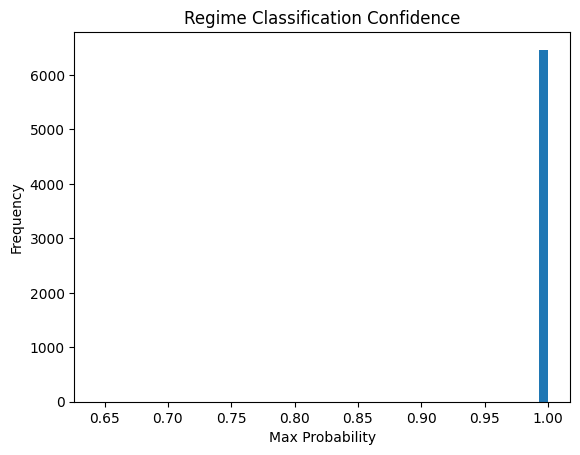

In [9]:
confidence = df[prob_cols].max(axis=1)

plt.hist(confidence, bins=50)
plt.title("Regime Classification Confidence")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")

plt.show()

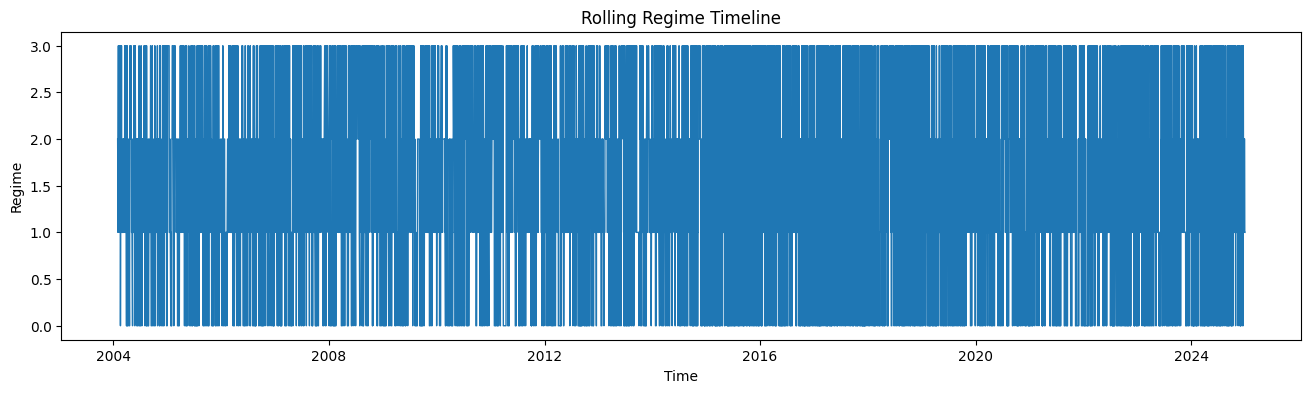

In [10]:
plt.figure(figsize=(16,4))

plt.plot(df.index, df["regime_state"], lw=1)

plt.title("Rolling Regime Timeline")
plt.ylabel("Regime")
plt.xlabel("Time")

plt.show()

In [11]:
vol_order = (
    df.groupby("regime_state")["spx_vol_20"]
    .mean()
    .sort_values()
    .index
)

mapping = {old: new for new, old in enumerate(vol_order)}

df["ordered_regime"] = df["regime_state"].map(mapping)

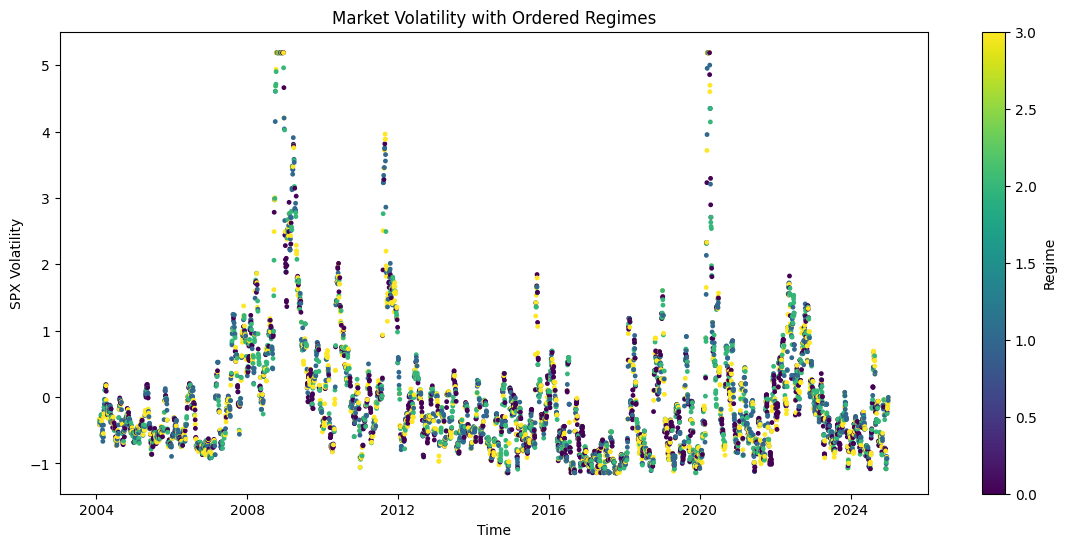

In [12]:
plt.figure(figsize=(14,6))

plt.scatter(
    df.index,
    df["spx_vol_20"],
    c=df["ordered_regime"],
    cmap="viridis",
    s=6
)

plt.title("Market Volatility with Ordered Regimes")
plt.xlabel("Time")
plt.ylabel("SPX Volatility")

plt.colorbar(label="Regime")

plt.show()

# Experiment 2 — Window Size Sensitivity

Goal:
Determine whether the instability in rolling HMM regimes is caused by
insufficient training data within each window.

We evaluate rolling HMM results for:

750-day window
1500-day window
3000-day window

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from src.regime_diagnostics import regime_summary, transition_matrix

In [14]:
def evaluate_regime_model(df, features):

    print("-------------")
    print("Regime Summary")
    print("-------------")

    summary = regime_summary(df, return_col="spx_sq_return")

    print(summary)

    print("\n-------------")
    print("Transition Matrix")
    print("-------------")

    tm = transition_matrix(df)

    print(tm)

    persistence = np.mean(np.diag(tm.values))

    print("\nAverage Persistence:", persistence)

    # silhouette score
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(df[features])

    sil = silhouette_score(X_scaled, df["regime_state"])

    print("\nSilhouette Score:", sil)

    return summary, tm, persistence, sil

In [15]:
features = [
    "spx_return",
    "spx_vol_20",
    "spx_vol_60",
    "vix_level",
    "stress_index",
    "us10y_vol"
]

In [16]:
df_750 = pd.read_parquet("../data/processed/regime_dataset_window_750.parquet")

summary_750, tm_750, persistence_750, sil_750 = evaluate_regime_model(df_750, features)

-------------
Regime Summary
-------------
   regime  count  mean_return  volatility   mean_vix  mean_stress
0       0   1575     0.000094    0.000240  18.803963    -0.110363
1       1   1576     0.000098    0.000246  18.854938    -0.176373
2       2   1647     0.000088    0.000224  18.014093    -0.343049
3       3   1687     0.000093    0.000222  19.013170    -0.127822

-------------
Transition Matrix
-------------
          0         1         2         3
0  0.436825  0.152381  0.180952  0.229841
1  0.166244  0.391497  0.195431  0.246827
2  0.182149  0.191864  0.419551  0.206436
3  0.192764  0.239027  0.214709  0.353499

Average Persistence: 0.4003432409684359

Silhouette Score: -0.028687775856807925


In [17]:
df_1500 = pd.read_parquet("../data/processed/regime_dataset_window_1500.parquet")

summary_1500, tm_1500, persistence_1500, sil_1500 = evaluate_regime_model(df_1500, features)

-------------
Regime Summary
-------------
   regime  count  mean_return  volatility   mean_vix  mean_stress
0       0   1463     0.000102    0.000238  19.591025    -0.068589
1       1   1390     0.000102    0.000260  19.313495    -0.123266
2       2   1339     0.000090    0.000227  19.213751    -0.077371
3       3   1543     0.000105    0.000255  19.201654    -0.043591

-------------
Transition Matrix
-------------
          0         1         2         3
0  0.460014  0.164730  0.164046  0.211210
1  0.156115  0.393525  0.197122  0.253237
2  0.195815  0.192078  0.387145  0.224963
3  0.200907  0.223590  0.198963  0.376539

Average Persistence: 0.40430576306368227

Silhouette Score: -0.014266087775581684


In [18]:
df_3000 = pd.read_parquet("../data/processed/regime_dataset_window_3000.parquet")

summary_3000, tm_3000, persistence_3000, sil_3000 = evaluate_regime_model(df_3000, features)

-------------
Regime Summary
-------------
   regime  count  mean_return  volatility   mean_vix  mean_stress
0       0   1122     0.000066    0.000185  17.534658    -0.569651
1       1    955     0.000063    0.000174  17.564867    -0.485656
2       2   1068     0.000075    0.000197  17.655456    -0.487492
3       3   1090     0.000070    0.000176  17.592943    -0.535353

-------------
Transition Matrix
-------------
          0         1         2         3
0  0.477718  0.139037  0.167558  0.215686
1  0.183438  0.431866  0.183438  0.201258
2  0.166667  0.179775  0.431648  0.221910
3  0.213761  0.178899  0.222936  0.384404

Average Persistence: 0.4314089494908053

Silhouette Score: -0.005743931955268991


In [19]:
comparison = pd.DataFrame({
    "window": [750,1500,3000],
    "persistence":[persistence_750, persistence_1500, persistence_3000],
    "silhouette":[sil_750, sil_1500, sil_3000]
})

comparison

,window,persistence,silhouette
0,750,0.400343,-0.028688
1,1500,0.404306,-0.014266
2,3000,0.431409,-0.005744


In [20]:
def plot_regimes(df, title):

    plt.figure(figsize=(14,6))

    scatter = plt.scatter(
        df.index,
        df["spx_vol_20"],
        c=df["regime_state"],
        cmap="tab10",
        s=5
    )

    plt.colorbar(scatter,label="Regime")

    plt.title(title)

    plt.xlabel("Time")
    plt.ylabel("SPX Volatility")

    plt.show()

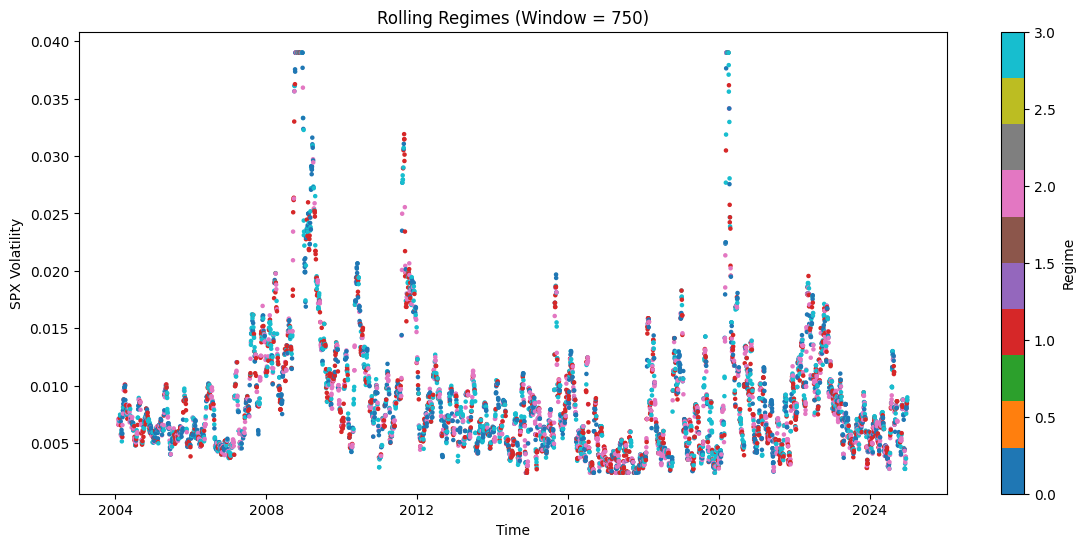

In [21]:
plot_regimes(df_750, "Rolling Regimes (Window = 750)")

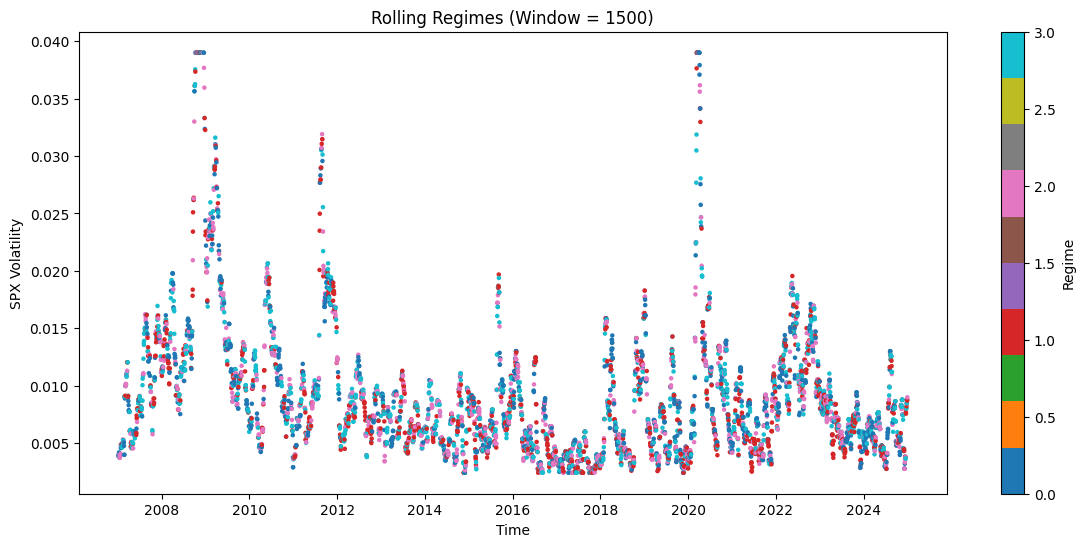

In [22]:
plot_regimes(df_1500, "Rolling Regimes (Window = 1500)")

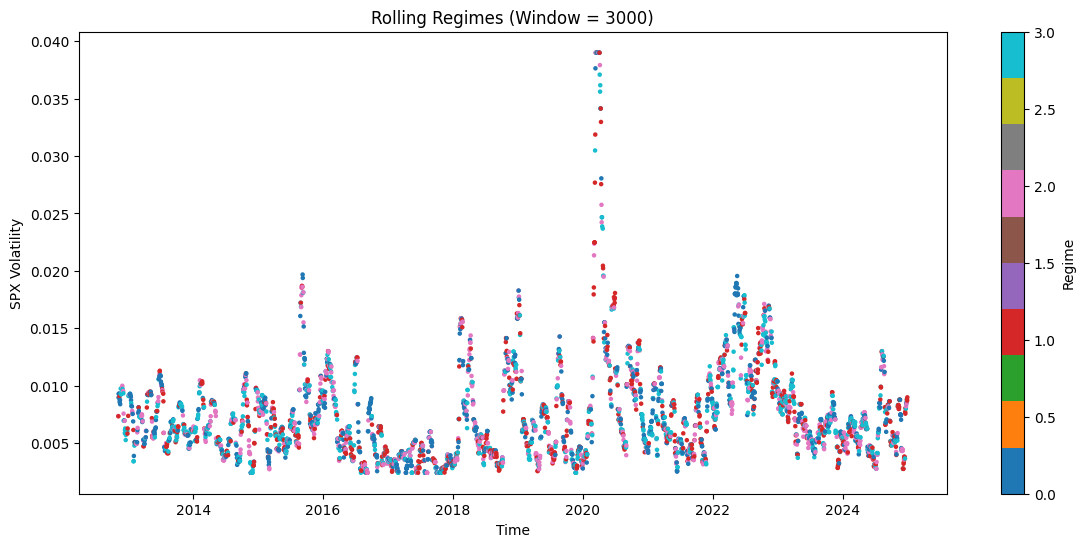

In [23]:
plot_regimes(df_3000, "Rolling Regimes (Window = 3000)")

# Global Model Training

In [24]:
import pandas as pd
df_global = pd.read_parquet("../data/processed/global_regime_dataset.parquet")

evaluate_regime_model(df_global, features)

-------------
Regime Summary
-------------
   regime  count  mean_return  volatility   mean_vix  mean_stress
0       0   1846     0.000076    0.000135  17.991306    -0.320812
1       1    868     0.000372    0.000511  34.130557     3.749790
2       2   2239     0.000023    0.000040  12.817548    -1.487831
3       3   2282     0.000097    0.000183  21.095048     0.145368

-------------
Transition Matrix
-------------
          0         1         2         3
0  0.971816  0.004878  0.015176  0.008130
1  0.000000  0.972350  0.000000  0.027650
2  0.015632  0.000000  0.982135  0.002233
3  0.007888  0.006573  0.005259  0.980280

Average Persistence: 0.9766453214890243

Silhouette Score: 0.1081565535416996


(   regime  count  mean_return  volatility   mean_vix  mean_stress
 0       0   1846     0.000076    0.000135  17.991306    -0.320812
 1       1    868     0.000372    0.000511  34.130557     3.749790
 2       2   2239     0.000023    0.000040  12.817548    -1.487831
 3       3   2282     0.000097    0.000183  21.095048     0.145368,
           0         1         2         3
 0  0.971816  0.004878  0.015176  0.008130
 1  0.000000  0.972350  0.000000  0.027650
 2  0.015632  0.000000  0.982135  0.002233
 3  0.007888  0.006573  0.005259  0.980280,
 np.float64(0.9766453214890243),
 0.1081565535416996)

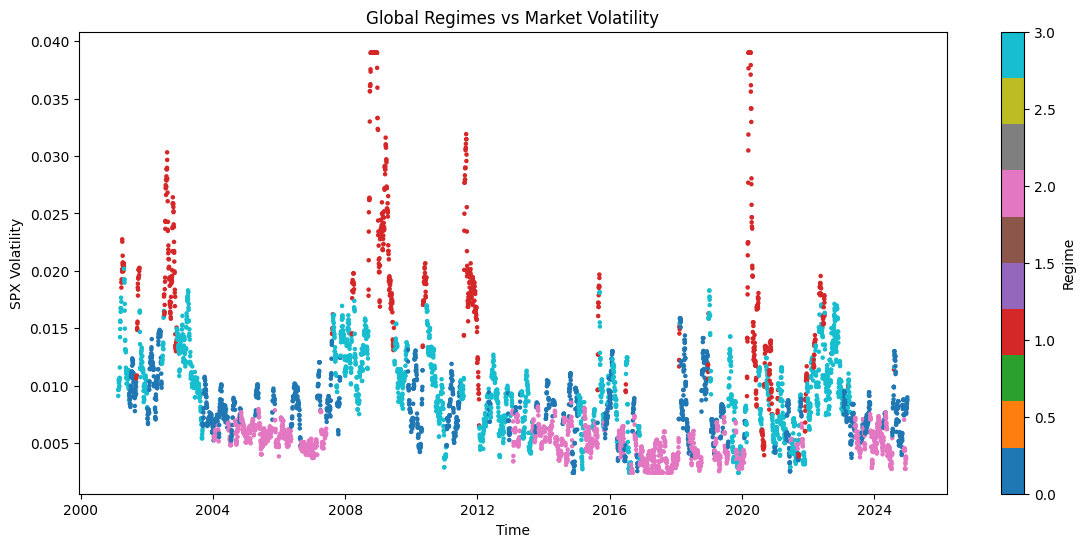

In [25]:
plt.figure(figsize=(14,6))

plt.scatter(
    df_global.index,
    df_global["spx_vol_20"],
    c=df_global["regime_state"],
    cmap="tab10",
    s=5
)

plt.title("Global Regimes vs Market Volatility")
plt.xlabel("Time")
plt.ylabel("SPX Volatility")

plt.colorbar(label="Regime")

plt.show()